# Interactive Superpixel Segmentation
Explore and compare different superpixel algorithms (Quickshift, Felzenszwalb, SLIC, Watershed) with adjustable parameters using interactive widgets.

In [ ]:
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.segmentation import quickshift, felzenszwalb, slic, watershed, mark_boundaries
from skimage.color import rgb2gray
from skimage.filters import sobel
import ipywidgets as widgets
from ipywidgets import interact, fixed
%matplotlib inline

(-0.5, 511.5, 511.5, -0.5)

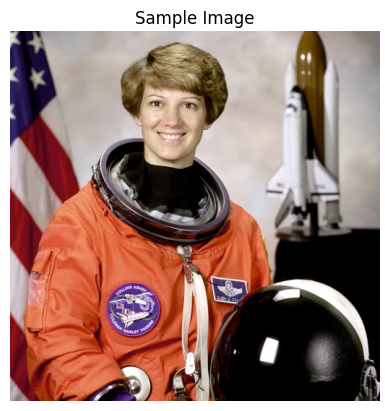

In [7]:
# Load a sample image (astronaut) and convert to float
image = img_as_float(data.astronaut())
plt.imshow(image)
plt.title('Sample Image')
plt.axis('off')

In [8]:
def seg_quickshift(img, kernel_size, max_dist, ratio):
    return quickshift(img, kernel_size=kernel_size, max_dist=max_dist, ratio=ratio)

def seg_felzenszwalb(img, scale, sigma, min_size):
    return felzenszwalb(img, scale=scale, sigma=sigma, min_size=min_size)

def seg_slic(img, n_segments, compactness, sigma):
    return slic(img, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=1)

def seg_watershed(img, markers, compactness):
    gradient = sobel(rgb2gray(img))
    return watershed(gradient, markers=markers, compactness=compactness)

In [9]:
def display_segmentation(algorithm, 
                         k_size, max_dist, ratio,    # quickshift
                         scale, sigma, min_size,      # felzenszwalb
                         n_segments, compactness, sigma_slic,  # slic
                         markers, compactness_ws):     # watershed
    # Select segmentation
    if algorithm == 'Quickshift':
        segments = seg_quickshift(image, k_size, max_dist, ratio)
    elif algorithm == 'Felzenszwalb':
        segments = seg_felzenszwalb(image, scale, sigma, min_size)
    elif algorithm == 'SLIC':
        segments = seg_slic(image, n_segments, compactness, sigma_slic)
    else:
        segments = seg_watershed(image, markers, compactness_ws)

    # Display
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(image)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(mark_boundaries(image, segments))
    ax[1].set_title(f'Segmentation: {algorithm}')
    ax[1].axis('off')
    plt.show()

In [10]:
interact(
    display_segmentation,
    algorithm=widgets.Dropdown(
        options=['Quickshift', 'Felzenszwalb', 'SLIC', 'Watershed'],
        value='Felzenszwalb',
        description='Algorithm:'
    ),
    # Quickshift params
    k_size=widgets.IntSlider(min=1, max=10, step=1, value=4, description='Kernel Size'),
    max_dist=widgets.IntSlider(min=1, max=20, step=1, value=10, description='Max Dist'),
    ratio=widgets.FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='Ratio'),
    # Felzenszwalb params
    scale=widgets.IntSlider(min=10, max=200, step=10, value=100, description='Scale'),
    sigma=widgets.FloatSlider(min=0.0, max=5.0, step=0.5, value=0.5, description='Sigma'),
    min_size=widgets.IntSlider(min=10, max=100, step=10, value=50, description='Min Size'),
    # SLIC params
    n_segments=widgets.IntSlider(min=50, max=400, step=50, value=100, description='N Segments'),
    compactness=widgets.FloatSlider(min=0.1, max=10.0, step=0.5, value=10.0, description='Compactness'),
    sigma_slic=widgets.FloatSlider(min=0.0, max=5.0, step=0.5, value=1.0, description='Sigma SLIC'),
    # Watershed params
    markers=widgets.IntSlider(min=2, max=50, step=1, value=10, description='Markers'),
    compactness_ws=widgets.FloatSlider(min=0.0, max=10.0, step=0.5, value=0.0, description='Compactness WS')
)

interactive(children=(Dropdown(description='Algorithm:', index=1, options=('Quickshift', 'Felzenszwalb', 'SLIC…

<function __main__.display_segmentation(algorithm, k_size, max_dist, ratio, scale, sigma, min_size, n_segments, compactness, sigma_slic, markers, compactness_ws)>

## Compare algorithms

Saved figure to: segmentation_comparison.pdf


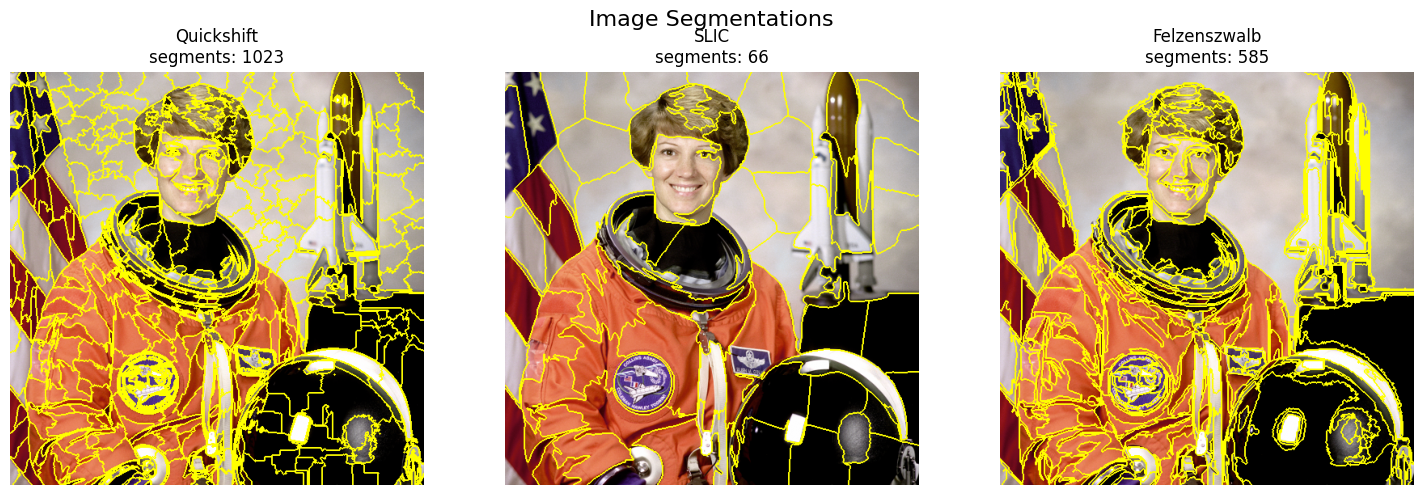

In [11]:
def compare_segmentations(
    # Quickshift parameters
    qs_kernel_size: int = 4,
    qs_max_dist: int = 10,
    qs_ratio: float = 1.0,
    # SLIC parameters
    slic_n_segments: int = 100,
    slic_compactness: float = 10.0,
    slic_sigma: float = 1.0,
    # Felzenszwalb parameters
    felz_scale: int = 100,
    felz_sigma: float = 0.5,
    felz_min_size: int = 50,
    pdf_name = out_path("segmentation_comparison.pdf"),
):
    """Segment an image with three algorithms and save a comparison PDF."""

    # --- run the three algorithms ------------------------------------------------
    seg_quick = quickshift(
        image,
        kernel_size=qs_kernel_size,
        max_dist=qs_max_dist,
        ratio=qs_ratio,
    )
    seg_slic = slic(
        image,
        n_segments=slic_n_segments,
        compactness=slic_compactness,
        sigma=slic_sigma,
        start_label=1,
    )
    seg_felz = felzenszwalb(
        image,
        scale=felz_scale,
        sigma=felz_sigma,
        min_size=felz_min_size,
    )

    # --- plot --------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
    for ax, seg, title in zip(
        axes.ravel(),
        (seg_quick, seg_slic, seg_felz),
        ("Quickshift", "SLIC", "Felzenszwalb"),
    ):
        ax.imshow(mark_boundaries(image, seg, mode="thick"))
        ax.set_title(f"{title}\nsegments: {seg.max() + 1}")
        ax.axis("off")

    fig.suptitle("Image Segmentations", fontsize=16)
    fig.tight_layout()

    # --- save --------------------------------------------------------------------
    plt.savefig(pdf_name, bbox_inches="tight")
    print(f"Saved figure to: {pdf_name}")

if __name__ == "__main__":
    compare_segmentations()
